In [1]:
import pandas as pd
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [2]:
# Load dataset
df = pd.read_csv("Sentiment_Data.csv", encoding='ISO-8859-1')

In [3]:
# Function for regex-based text cleaning
def clean_text(text):
    text = re.sub(r"http\S+|www\S+", "", text)         # Remove URLs
    text = re.sub(r"@\w+", "", text)                   # Remove mentions
    text = re.sub(r"#\w+", "", text)                   # Remove hashtags
    text = re.sub(r"[^\w\s.,!?]", "", text)            # Remove emojis/special chars
    text = re.sub(r"\s+", " ", text).strip()           # Remove extra whitespace
    return text

In [4]:
# Apply cleaning
df['Clean_Tweet'] = df['Tweet'].astype(str).apply(clean_text)

In [5]:
# Label encoding
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Sentiment'])

In [6]:
# Class distribution (optional view)
print(df['Sentiment'].value_counts())

Sentiment
Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: count, dtype: int64


In [7]:
# Train-test split (10% test set ensures ≥5000 samples)
train_df, test_df = train_test_split(df, test_size=0.1, stratify=df['Label'], random_state=42)

In [8]:
# Apply to the dataset
df['Clean_Tweet'] = df['Tweet'].astype(str).apply(clean_text)

In [9]:
# View result
print(df[['Tweet', 'Clean_Tweet']].head())

                                               Tweet  \
0  @_angelica_toy Happy Anniversary!!!....The Day...   
1  @McfarlaneGlenda Happy Anniversary!!!....The D...   
2  @thevivafrei @JustinTrudeau Happy Anniversary!...   
3  @NChartierET Happy Anniversary!!!....The Day t...   
4  @tabithapeters05 Happy Anniversary!!!....The D...   

                                         Clean_Tweet  
0  Happy Anniversary!!!....The Day the FreeDUMB D...  
1  Happy Anniversary!!!....The Day the FreeDUMB D...  
2  Happy Anniversary!!!....The Day the FreeDUMB D...  
3  Happy Anniversary!!!....The Day the FreeDUMB D...  
4  Happy Anniversary!!!....The Day the FreeDUMB D...  


In [10]:
# Install the emoji library
!pip install emoji


In [11]:
# Import the emoji library
import emoji

In [12]:
# Example slang/abbreviation dictionary
slang_dict = {
    "u": "you",
    "ur": "your",
    "lol": "laugh out loud",
    "omg": "oh my god",
    "idk": "I don't know",
    "btw": "by the way",
    "gr8": "great",
    "thx": "thanks",
    "pls": "please",
    "imo": "in my opinion"
}


In [13]:
# Function to expand slang/abbreviations
def expand_slang(text):
    words = text.split()
    return ' '.join([slang_dict.get(word.lower(), word) for word in words])


In [14]:
# Function to remove emojis
def remove_emojis(text):
    return emoji.replace_emoji(text, replace='')

In [15]:
# Combine everything: clean + expand + remove emojis
def clean_and_normalize(text):
    text = re.sub(r"http\S+|www\S+", "", text)         # Remove URLs
    text = re.sub(r"@\w+", "", text)                   # Remove mentions
    text = re.sub(r"#\w+", "", text)                   # Remove hashtags
    text = remove_emojis(text)                         # Remove emojis
    text = expand_slang(text)                          # Expand slang/abbreviations
    text = re.sub(r"[^\w\s.,!?]", "", text)            # Remove special characters
    text = re.sub(r"\s+", " ", text).strip()           # Normalize whitespace
    return text


In [17]:
# Apply to DataFrame
df = pd.read_csv("Sentiment_Data.csv", encoding='ISO-8859-1')
df['Clean_Tweet'] = df['Tweet'].astype(str).apply(clean_and_normalize)


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [19]:
# Encode sentiment labels (if not already done)
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Sentiment'])

In [20]:
# Perform stratified split (e.g., 10% test set = 45,000+ samples in your case)
train_df, test_df = train_test_split(
    df,
    test_size=0.1,                # 10% test set
    stratify=df['Label'],         # Ensure class distribution remains balanced
    random_state=42
)

In [21]:
# Confirm split sizes
print(f"Train samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")  # Should be > 5000

Train samples: 406198
Test samples: 45134


In [22]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
# Label Encoding
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Sentiment'])


In [24]:
# View mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:")
print(label_mapping)


Label Mapping:
{'Mild_Neg': 0, 'Mild_Pos': 1, 'Neutral': 2, 'Strong_Neg': 3, 'Strong_Pos': 4}


In [25]:
# Class Balance (Value Counts)
print("\nClass Distribution:")
print(df['Sentiment'].value_counts())


Class Distribution:
Sentiment
Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: count, dtype: int64


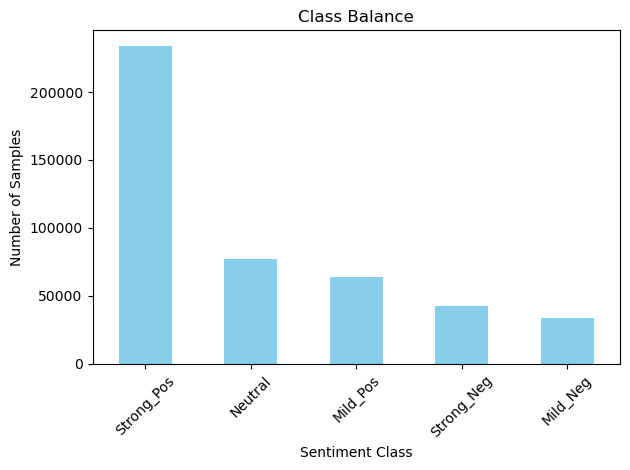

In [26]:

# Optional: Visualize class distribution
df['Sentiment'].value_counts().plot(kind='bar', title='Class Balance', color='skyblue')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# LSTM with Word2Vec

In [27]:
from gensim.models import Word2Vec

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451332 entries, 0 to 451331
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Tweet        451331 non-null  object
 1   Sentiment    451332 non-null  object
 2   Clean_Tweet  451332 non-null  object
 3   Label        451332 non-null  int32 
dtypes: int32(1), object(3)
memory usage: 12.1+ MB


In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from gensim.models import Word2Vec
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
df['tokens'] = df['Clean_Tweet'].apply(lambda x: str(x).split())

In [32]:
X_texts = df['tokens']
y = df['Label']

In [33]:
w2v_model = Word2Vec(sentences=X_texts, vector_size=100, window=5, min_count=1, sg=0)

In [34]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_texts)
sequences = tokenizer.texts_to_sequences(X_texts)
padded = pad_sequences(sequences, padding='post')

vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 100

In [36]:
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

In [37]:
from tensorflow.keras.utils import to_categorical
y_cat = to_categorical(y)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(padded, y_cat, test_size=0.3, stratify=y_cat, random_state=42)

In [39]:
def build_lstm_model(lstm_units):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=padded.shape[1],
    trainable=False))
    model.add(LSTM(lstm_units))
    model.add(Dense(y_cat.shape[1], activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

for units in [64, 128, 256]:
    print(f"\nTraining with LSTM units = {units}")
    model = build_lstm_model(units)
    model.fit(X_train, y_train, validation_split=0.1, epochs=3, batch_size=32)
    score = model.evaluate(X_test, y_test)
    print(f"Test Accuracy with {units} units: {score[1]:.4f}")


Training with LSTM units = 64


C:\Users\Administrator\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
8886/8886 ━━━━━━━━━━━━━━━━━━━━ 306s 34ms/step - accuracy: 0.5425 - loss: 1.2949 - val_accuracy: 0.6544 - val_loss: 0.9286
Epoch 2/3
8886/8886 ━━━━━━━━━━━━━━━━━━━━ 299s 34ms/step - accuracy: 0.6768 - loss: 0.8684 - val_accuracy: 0.7115 - val_loss: 0.7906
Epoch 3/3
8886/8886 ━━━━━━━━━━━━━━━━━━━━ 266s 30ms/step - accuracy: 0.7226 - loss: 0.7494 - val_accuracy: 0.7296 - val_loss: 0.7341
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 54s 13ms/step - accuracy: 0.7292 - loss: 0.7295
Test Accuracy with 64 units: 0.7309

Training with LSTM units = 128
Epoch 1/3
8886/8886 ━━━━━━━━━━━━━━━━━━━━ 426s 48ms/step - accuracy: 0.5633 - loss: 1.2110 - val_accuracy: 0.6893 - val_loss: 0.8473
Epoch 2/3
8886/8886 ━━━━━━━━━━━━━━━━━━━━ 428s 48ms/step - accuracy: 0.7059 - loss: 0.7982 - val_accuracy: 0.7287 - val_loss: 0.7467
Epoch 3/3
8886/8886 ━━━━━━━━━━━━━━━━━━━━ 427s 48ms/step - accuracy: 0.7373 - loss: 0.7118 - val_accuracy: 0.7443 - val_loss: 0.6968
4232/4232 ━━━━━━━━━━━━━━━━━━━━ 110s 26ms/step - accuracy: 0.7

4232/4232 ━━━━━━━━━━━━━━━━━━━━ 260s 61ms/step
              precision    recall  f1-score   support

           0       0.61      0.34      0.43     10217
           1       0.60      0.51      0.55     19201
           2       0.73      0.67      0.70     23105
           3       0.62      0.76      0.68     12767
           4       0.85      0.93      0.89     70110

    accuracy                           0.76    135400
   macro avg       0.68      0.64      0.65    135400
weighted avg       0.75      0.76      0.75    135400



<Axes: >

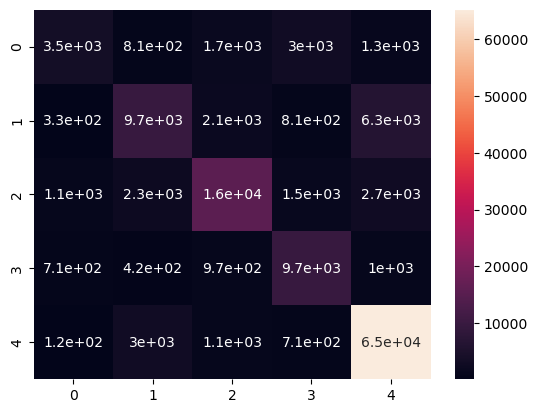

In [40]:
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_labels))
sns.heatmap(confusion_matrix(y_true, y_pred_labels), annot=True)

In [41]:
model.save("lstm_word2vec_model.h5")
print("Model saved as lstm_word2vec_model.h5")

Model saved as lstm_word2vec_model.h5


In [43]:
from tensorflow.keras.models import load_model
model = load_model("lstm_word2vec_model.h5")

In [44]:
# Get 10 random samples from the test set
sample_indices = np.random.choice(np.arange(len(X_test)), size=10, replace=False)
X_sample = X_test[sample_indices]
y_true_sample = np.argmax(y_test[sample_indices], axis=1)

# Predict
y_pred_sample = model.predict(X_sample)
y_pred_labels = np.argmax(y_pred_sample, axis=1)

# map back to sentiment labels
label_map = dict(enumerate(df['Sentiment'].astype('category').cat.categories))

#Display results
for i, idx in enumerate(sample_indices):
    print(f"Sample {i+1}:")
    print(f"Original Tweet: {' '.join(df.iloc[idx]['tokens'])}")
    print(f"True Label: {label_map[y_true_sample[i]]}")
    print(f"Predicted Label: {label_map[y_pred_labels[i]]}")
    print("—" * 60)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
Sample 1:
Original Tweet: Heres a great compilation of Trudeaus discriminatory remarks about the trucker freedom convoy
True Label: Strong_Pos
Predicted Label: Strong_Pos
————————————————————————————————————————————————————————————
Sample 2:
Original Tweet: If they return I will be back out on the streets with them, gas can around my neck, Canada flag as a cape, with my Honk for Freedom sign!
True Label: Strong_Pos
Predicted Label: Strong_Pos
————————————————————————————————————————————————————————————
Sample 3:
Original Tweet: Freedom Convoy protest in Winnipeg called off CTV News
True Label: Strong_Neg
Predicted Label: Strong_Neg
————————————————————————————————————————————————————————————
Sample 4:
Original Tweet: Witness after witness for the government say that Tow Truck Companies refused to tow at the because of threats to their livelihoods. They didnt because of their support for the Convoy. The government got them to tow trucks by THREATEN